# LLM Syscall Log — Exploratory Data Analysis
Data source: `logs/llm_syscalls.jsonl`

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import os

# Force working directory to project root
os.chdir(r'C:\Users\mpstme.student\AIOS-Cognitive')

sns.set_theme(style='whitegrid')
LOG_PATH = r'C:\Users\mpstme.student\AIOS-Cognitive\aios\logs\llm_syscalls.jsonl'
print(LOG_PATH)  # should show: C:\Users\mpstme.student\AIOS-Cognitive\logs\llm_syscalls.jsonl

rows = [json.loads(l) for l in open(LOG_PATH) if l.strip()]
df = pd.DataFrame(rows)
df['has_tools'] = df['has_tools'].astype(bool)

print(f'Shape: {df.shape}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head()

C:\Users\mpstme.student\AIOS-Cognitive\aios\logs\llm_syscalls.jsonl
Shape: (500, 15)

Dtypes:
syscall_id            object
agent_name            object
timestamp            float64
input_char_length      int64
message_count          int64
has_tools               bool
max_tokens             int64
temperature          float64
created_time         float64
start_time           float64
end_time             float64
latency_ms           float64
wait_ms              float64
was_interrupted         bool
error                   bool
dtype: object

Null counts:
syscall_id           0
agent_name           0
timestamp            0
input_char_length    0
message_count        0
has_tools            0
max_tokens           0
temperature          0
created_time         0
start_time           0
end_time             0
latency_ms           0
wait_ms              0
was_interrupted      0
error                0
dtype: int64


,syscall_id,agent_name,timestamp,input_char_length,message_count,has_tools,max_tokens,temperature,created_time,start_time,end_time,latency_ms,wait_ms,was_interrupted,error
0,770cfcfc-e460-4a87-8dce-31667befb727,short_qa_agent_r1,1.774527e+09,185,2,False,100,0.3,1.774527e+09,1.774527e+09,1.774527e+09,24281.689882,624.788046,False,False
1,3246129b-ce7c-4ade-a9e7-ac2a86dc7775,long_reasoning_agent_r1,1.774527e+09,519,2,False,1024,0.7,1.774527e+09,1.774527e+09,1.774527e+09,24282.689571,623.787642,False,False
2,db5711fb-8f91-4c9c-8c74-acb46fd8bd7e,code_gen_agent_r1,1.774527e+09,651,2,False,2048,0.2,1.774527e+09,1.774527e+09,1.774527e+09,24248.567343,658.195734,False,False
3,ed9e60df-057e-4751-abdc-2163f5937f97,summarizer_agent_r1,1.774527e+09,1615,2,False,256,0.4,1.774527e+09,1.774527e+09,1.774527e+09,24243.915796,663.841486,False,False
4,44eb5268-8869-48d3-9769-2cf4e68bd171,tool_use_agent_r1,1.774527e+09,314,2,True,512,0.5,1.774527e+09,1.774527e+09,1.774527e+09,24237.825394,669.931889,False,False


## 1 · Latency Distribution

latency_ms stats (ms):
  min    : 12,001
  p25    : 16,212
  median : 18,160
  mean   : 18,366
  p75    : 20,294
  p90    : 21,886
  max    : 26,377
  std    : 2,932


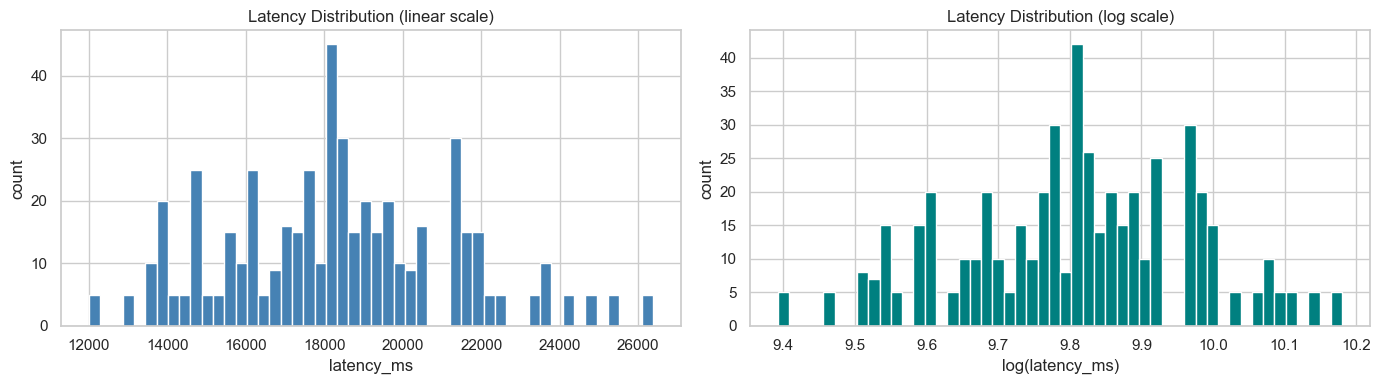

In [6]:
stats = df['latency_ms'].describe(percentiles=[.25, .75, .90])
print('latency_ms stats (ms):')
print(f'  min    : {df.latency_ms.min():,.0f}')
print(f'  p25    : {df.latency_ms.quantile(.25):,.0f}')
print(f'  median : {df.latency_ms.median():,.0f}')
print(f'  mean   : {df.latency_ms.mean():,.0f}')
print(f'  p75    : {df.latency_ms.quantile(.75):,.0f}')
print(f'  p90    : {df.latency_ms.quantile(.90):,.0f}')
print(f'  max    : {df.latency_ms.max():,.0f}')
print(f'  std    : {df.latency_ms.std():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['latency_ms'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Latency Distribution (linear scale)')
axes[0].set_xlabel('latency_ms')
axes[0].set_ylabel('count')

axes[1].hist(np.log(df['latency_ms']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Latency Distribution (log scale)')
axes[1].set_xlabel('log(latency_ms)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## 2 · Complexity Labels (Approach 2 — Classifier target)

Class distribution:
  fast    :  500  (100.0%)
  medium  :    0  (0.0%)  ⚠️  < 10% — class imbalance!
  large   :    0  (0.0%)  ⚠️  < 10% — class imbalance!


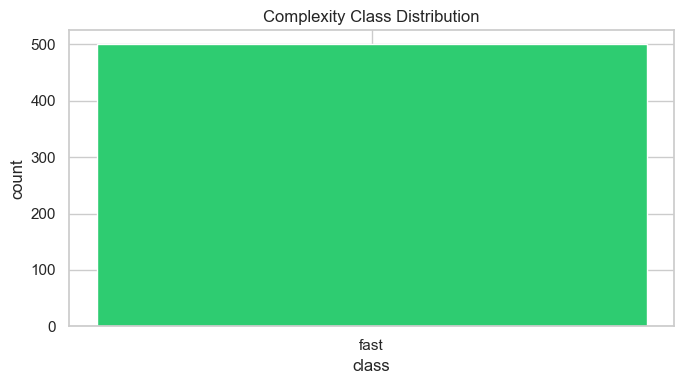

In [7]:
def label(ms):
    if ms < 70_000:  return 'fast'
    if ms < 150_000: return 'medium'
    return 'large'

df['complexity'] = df['latency_ms'].apply(label)

counts = df['complexity'].value_counts()
pcts   = df['complexity'].value_counts(normalize=True) * 100

print('Class distribution:')
for cls in ['fast', 'medium', 'large']:
    n   = counts.get(cls, 0)
    pct = pcts.get(cls, 0)
    warn = '  ⚠️  < 10% — class imbalance!' if pct < 10 else ''
    print(f'  {cls:8s}: {n:>4}  ({pct:.1f}%){warn}')

fig, ax = plt.subplots(figsize=(7, 4))
order = ['fast', 'medium', 'large']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.bar([c for c in order if c in counts],
       [counts.get(c, 0) for c in order if c in counts],
       color=[colors[i] for i, c in enumerate(order) if c in counts])
ax.set_title('Complexity Class Distribution')
ax.set_xlabel('class')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 3 · Feature Distributions

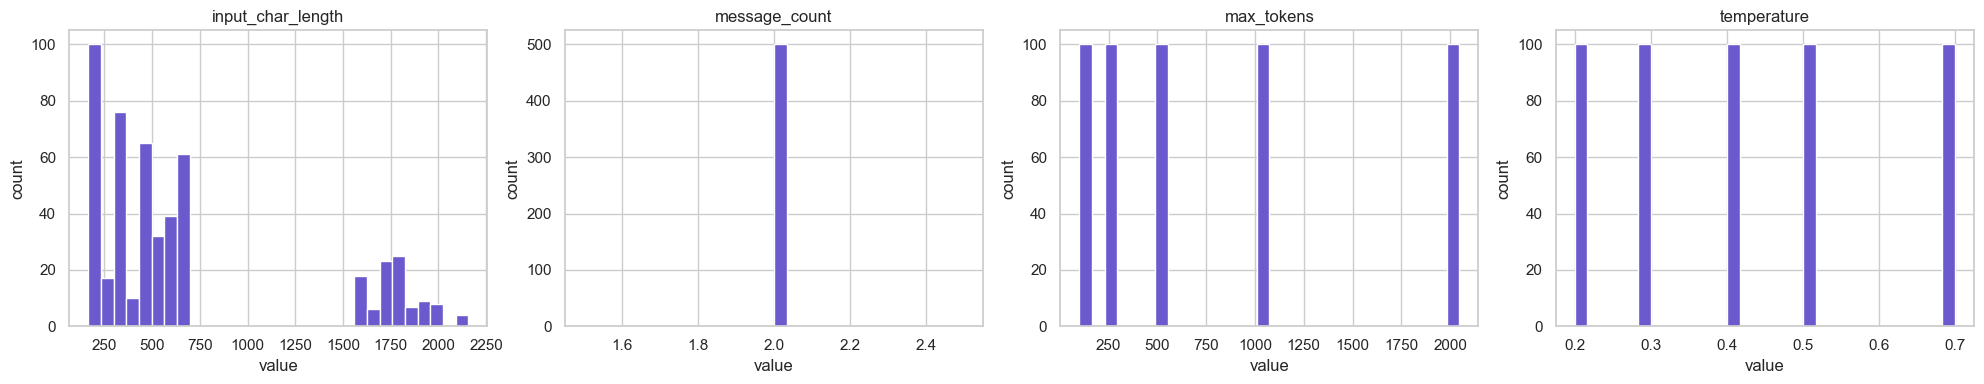

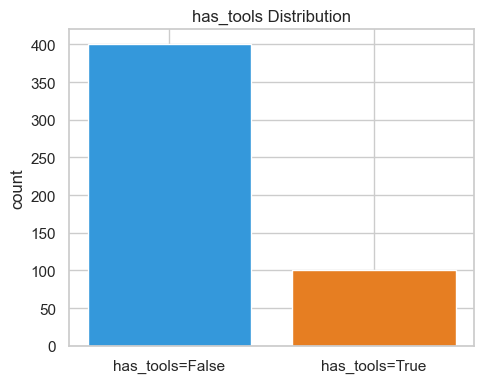

In [8]:
num_features = ['input_char_length', 'message_count', 'max_tokens', 'temperature']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, feat in zip(axes, num_features):
    ax.hist(df[feat], bins=30, color='slateblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# has_tools bar
fig, ax = plt.subplots(figsize=(5, 4))
vc = df['has_tools'].value_counts()
ax.bar(['has_tools=False', 'has_tools=True'],
       [vc.get(False, 0), vc.get(True, 0)],
       color=['#3498db', '#e67e22'])
ax.set_title('has_tools Distribution')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 4 · Feature vs Latency Correlations


Feature                    Pearson r   Spearman ρ
--------------------------------------------------
input_char_length              0.006        0.018
message_count                    nan          nan
has_tools                     -0.000       -0.000
max_tokens                     0.000        0.001
temperature                    0.000       -0.000


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_7564\535849272.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr, _ = pearsonr(df_num[feat], df_num['latency_ms'])
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_7564\535849272.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sr, _ = spearmanr(df_num[feat], df_num['latency_ms'])


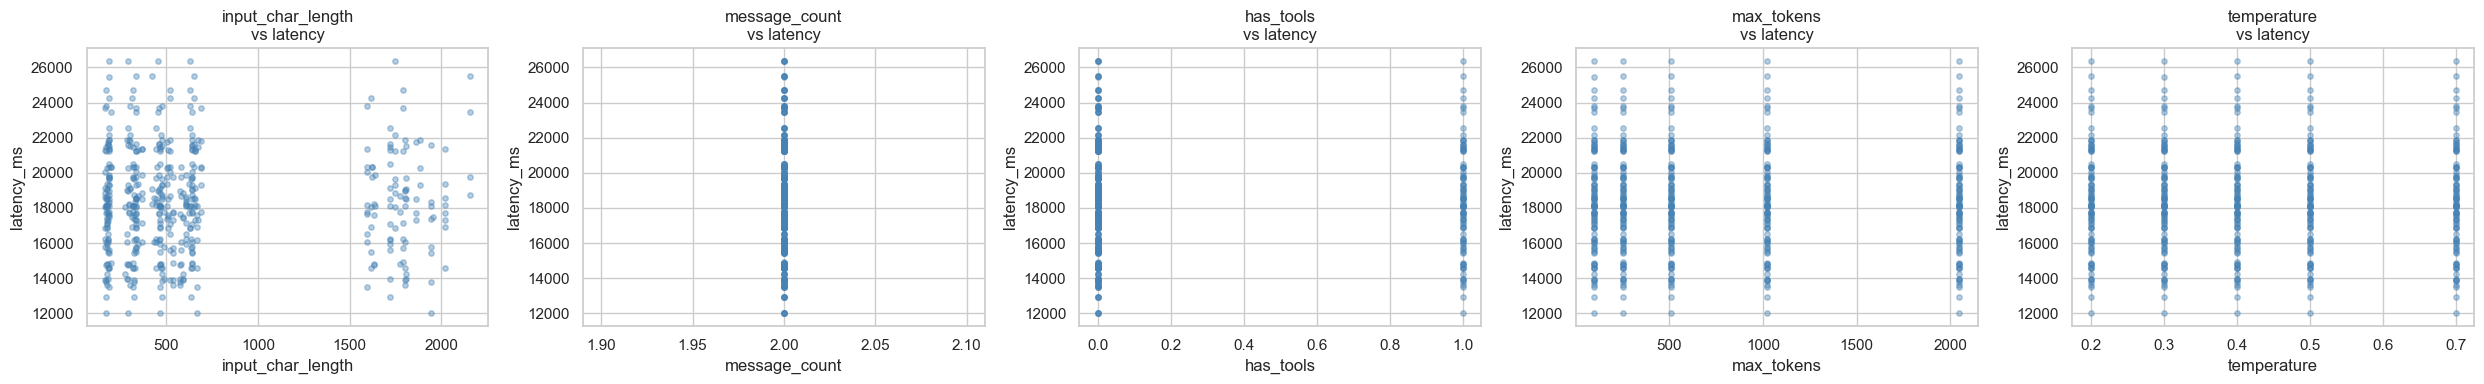

In [9]:
features = ['input_char_length', 'message_count', 'has_tools', 'max_tokens', 'temperature']
df_num = df.copy()
df_num['has_tools'] = df_num['has_tools'].astype(int)

print(f'\n{"Feature":<25} {"Pearson r":>10} {"Spearman ρ":>12}')
print('-' * 50)
for feat in features:
    pr, _ = pearsonr(df_num[feat], df_num['latency_ms'])
    sr, _ = spearmanr(df_num[feat], df_num['latency_ms'])
    print(f'{feat:<25} {pr:>10.3f} {sr:>12.3f}')

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, feat in zip(axes, features):
    ax.scatter(df_num[feat], df_num['latency_ms'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('latency_ms')
    ax.set_title(f'{feat}\nvs latency')
plt.tight_layout()
plt.show()

## 5 · Correlation Heatmap

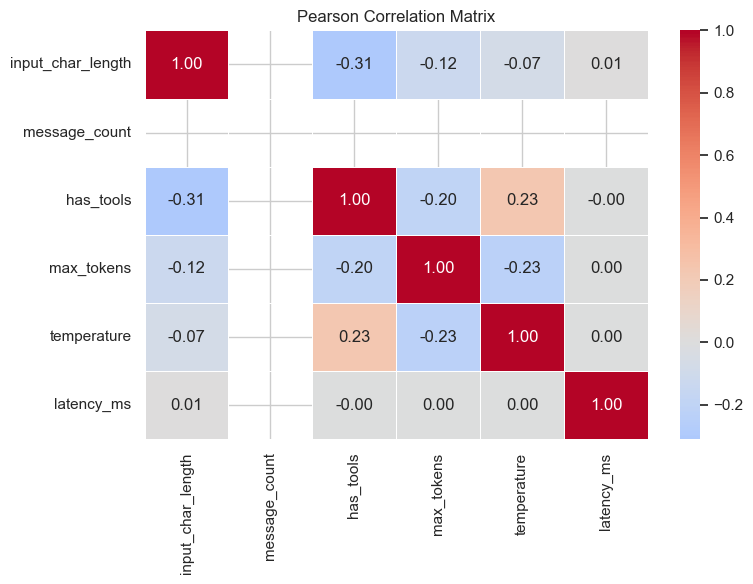

In [10]:
corr_cols = ['input_char_length', 'message_count', 'has_tools', 'max_tokens', 'temperature', 'latency_ms']
corr_df = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

## 6 · has_tools Box Plot

C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_7564\2927139540.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['has_tools=False', 'has_tools=True'], patch_artist=True,


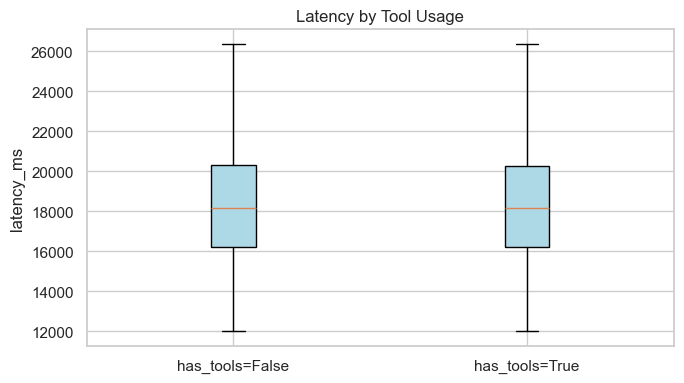

Median latency (ms):
  has_tools=False : 18,160
  has_tools=True  : 18,160


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = [df[df['has_tools'] == False]['latency_ms'].values,
          df[df['has_tools'] == True]['latency_ms'].values]
ax.boxplot(groups, labels=['has_tools=False', 'has_tools=True'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_ylabel('latency_ms')
ax.set_title('Latency by Tool Usage')
plt.tight_layout()
plt.show()

print('Median latency (ms):')
print(f'  has_tools=False : {df[df.has_tools==False].latency_ms.median():,.0f}')
print(f'  has_tools=True  : {df[df.has_tools==True].latency_ms.median():,.0f}')

## 7 · Readiness Assessment

In [12]:
max_spearman = max(abs(spearmanr(df_num[f], df_num['latency_ms'])[0]) for f in features)
all_classes_ok = all(pcts.get(c, 0) >= 10 for c in ['fast', 'medium', 'large'])

ridge_ready = max_spearman >= 0.3
clf_ready   = all_classes_ok

print('=' * 50)
print('  READINESS ASSESSMENT')
print('=' * 50)
print(f'  Max Spearman ρ across features : {max_spearman:.3f}')
print(f'  Ridge ready (Approach 1)       : {"✅ YES" if ridge_ready else "❌ NO — ρ too low, collect more varied data"}')
print(f'  Classifier ready (Approach 2)  : {"✅ YES" if clf_ready else "❌ NO — class imbalance detected"}')
print()
if ridge_ready and clf_ready:
    print('  ✅ Recommendation: PROCEED TO TRAINING')
else:
    print('  ⚠️  Recommendation: COLLECT MORE DATA before training')
print('=' * 50)

  READINESS ASSESSMENT
  Max Spearman ρ across features : 0.018
  Ridge ready (Approach 1)       : ❌ NO — ρ too low, collect more varied data
  Classifier ready (Approach 2)  : ❌ NO — class imbalance detected

  ⚠️  Recommendation: COLLECT MORE DATA before training


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_7564\659771658.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  max_spearman = max(abs(spearmanr(df_num[f], df_num['latency_ms'])[0]) for f in features)
